In [1]:
from pathlib import Path
import sys
import pandas as pd
from tqdm import tqdm

sys.path.insert(0, str(Path('..').resolve()))

from lib.ai import vlmrun_score_aesthetic, gemini_score_aesthetic, gpt5_score_aesthetic

print("Multi-model aesthetic scoring setup complete")

Multi-model aesthetic scoring setup complete


In [2]:
# Load all spec renders
specs_dir = Path('../datasets/specs/')
spec_paths = sorted(list(specs_dir.glob('*/render.png')))

# Create dataframe with template IDs and render paths
specs_df = pd.DataFrame({
    'template_id': [p.parent.name for p in spec_paths],
    'render_path': spec_paths
})

print(f"Found {len(specs_df)} design spec renders")
specs_df.head()

Found 100 design spec renders


,template_id,render_path
0,1067w-IQprojiENUA,../datasets/specs/1067w-IQprojiENUA/render.png
1,1131w-02GXIIidf_4,../datasets/specs/1131w-02GXIIidf_4/render.png
2,1131w-120Kpwxx3eY,../datasets/specs/1131w-120Kpwxx3eY/render.png
3,1131w-50t2MzJLmsM,../datasets/specs/1131w-50t2MzJLmsM/render.png
4,1131w-9cN5biKALLQ,../datasets/specs/1131w-9cN5biKALLQ/render.png


In [6]:
# Score each render with all three models (parallelized)
from concurrent.futures import ThreadPoolExecutor, as_completed

def score_single_render_all_models(row):
    """Score a single render with all three models and return (template_id, vlmrun_score, gemini_score, gpt5_score)"""
    template_id = row['template_id']
    render_path = row['render_path']
    
    vlmrun_score = None
    gemini_score = None
    gpt5_score = None
    
    try:
        vlmrun_score = vlmrun_score_aesthetic(render_path)
    except Exception as e:
        print(f"VLM Run error for {template_id}: {e}")
    
    try:
        gemini_score = gemini_score_aesthetic(render_path)
    except Exception as e:
        print(f"Gemini error for {template_id}: {e}")
    
    try:
        gpt5_score = gpt5_score_aesthetic(render_path)
    except Exception as e:
        print(f"GPT-5 error for {template_id}: {e}")
    
    return template_id, vlmrun_score, gemini_score, gpt5_score

# Parallelize scoring with ThreadPoolExecutor
max_workers = 10
scores_dict = {}

print(f"Scoring {len(specs_df)} renders with 3 models using {max_workers} workers...")

with ThreadPoolExecutor(max_workers=max_workers) as executor:
    futures = {executor.submit(score_single_render_all_models, row): idx for idx, row in specs_df.iterrows()}
    
    for future in tqdm(as_completed(futures), total=len(futures), desc="Scoring aesthetics"):
        template_id, vlmrun_score, gemini_score, gpt5_score = future.result()
        scores_dict[template_id] = {
            'vlmrun_score': vlmrun_score,
            'gemini_score': gemini_score,
            'gpt5_score': gpt5_score
        }

# Map scores back to dataframe
specs_df['vlmrun_score'] = specs_df['template_id'].map(lambda x: scores_dict[x]['vlmrun_score'])
specs_df['gemini_score'] = specs_df['template_id'].map(lambda x: scores_dict[x]['gemini_score'])
specs_df['gpt5_score'] = specs_df['template_id'].map(lambda x: scores_dict[x]['gpt5_score'])

print(f"\nCompleted scoring {len(specs_df)} renders with all 3 models")
specs_df.head()

Scoring 10 renders with 3 models using 10 workers...


Scoring aesthetics:   0%|          | 0/10 [00:00<?, ?it/s]

2025-11-19 14:46:53.112 | DEBUG    | vlmrun.client.files:get_cached_file:58 - Computing md5 hash for file [file=../datasets/specs/1600w-eqZAnXprFhg/render.png]
2025-11-19 14:46:53.114 | DEBUG    | vlmrun.client.files:get_cached_file:64 - Computed md5 hash for file [file=../datasets/specs/1600w-eqZAnXprFhg/render.png, hash=4a99c5315c736c68611b109eff8dd426]
2025-11-19 14:46:53.114 | DEBUG    | vlmrun.client.files:get_cached_file:67 - Checking if file exists in the database [file=../datasets/specs/1600w-eqZAnXprFhg/render.png, hash=4a99c5315c736c68611b109eff8dd426]
2025-11-19 14:46:53.118 | DEBUG    | vlmrun.client.files:get_cached_file:58 - Computing md5 hash for file [file=../datasets/specs/1131w-sSnAV2dB_qg/render.png]
2025-11-19 14:46:53.120 | DEBUG    | vlmrun.client.files:get_cached_file:64 - Computed md5 hash for file [file=../datasets/specs/1131w-sSnAV2dB_qg/render.png, hash=b0fd4cf7d90952575f821c5569b0dba4]
2025-11-19 14:46:53.121 | DEBUG    | vlmrun.client.files:get_cached_file:


Completed scoring 10 renders with all 3 models


,template_id,render_path,vlmrun_score,gemini_score,gpt5_score
1,1131w-02GXIIidf_4,../datasets/specs/1131w-02GXIIidf_4/render.png,26.0,91.0,94.0
50,1600w-9JTrLkx-Ppg,../datasets/specs/1600w-9JTrLkx-Ppg/render.png,94.0,58.0,94.0
79,1600w-eqZAnXprFhg,../datasets/specs/1600w-eqZAnXprFhg/render.png,10.0,74.0,68.0
14,1131w-sSnAV2dB_qg,../datasets/specs/1131w-sSnAV2dB_qg/render.png,60.0,91.0,94.0
15,1131w-tpnRumgzO8o,../datasets/specs/1131w-tpnRumgzO8o/render.png,97.0,71.0,96.0


In [7]:
# Save results to CSV
output_path = Path('spec_aesthetic_scores_comparison.csv')
specs_df.to_csv(output_path, index=False)
print(f"Saved results to {output_path}")

# Show summary statistics for each model
print(f"\n=== Score Summary by Model ===\n")
print("VLM Run:")
print(specs_df['vlmrun_score'].describe())
print("\nGemini:")
print(specs_df['gemini_score'].describe())
print("\nGPT-5:")
print(specs_df['gpt5_score'].describe())

specs_df

Saved results to spec_aesthetic_scores_comparison.csv

=== Score Summary by Model ===

VLM Run:
count    10.000000
mean     47.800000
std      40.490877
min       5.000000
25%       9.250000
50%      43.000000
75%      89.250000
max      97.000000
Name: vlmrun_score, dtype: float64

Gemini:
count    10.00000
mean     74.70000
std      13.25854
min      57.00000
25%      62.75000
50%      75.50000
75%      86.50000
max      91.00000
Name: gemini_score, dtype: float64

GPT-5:
count    10.000000
mean     89.300000
std       9.238206
min      68.000000
25%      91.000000
50%      93.500000
75%      94.000000
max      96.000000
Name: gpt5_score, dtype: float64


,template_id,render_path,vlmrun_score,gemini_score,gpt5_score
1,1131w-02GXIIidf_4,../datasets/specs/1131w-02GXIIidf_4/render.png,26.0,91.0,94.0
50,1600w-9JTrLkx-Ppg,../datasets/specs/1600w-9JTrLkx-Ppg/render.png,94.0,58.0,94.0
79,1600w-eqZAnXprFhg,../datasets/specs/1600w-eqZAnXprFhg/render.png,10.0,74.0,68.0
14,1131w-sSnAV2dB_qg,../datasets/specs/1131w-sSnAV2dB_qg/render.png,60.0,91.0,94.0
15,1131w-tpnRumgzO8o,../datasets/specs/1131w-tpnRumgzO8o/render.png,97.0,71.0,96.0
4,1131w-9cN5biKALLQ,../datasets/specs/1131w-9cN5biKALLQ/render.png,9.0,79.0,95.0
94,848w-a7AVmpGZf5E,../datasets/specs/848w-a7AVmpGZf5E/render.png,96.0,89.0,91.0
40,1280w-l2k_WnNosUU,../datasets/specs/1280w-l2k_WnNosUU/render.png,75.0,57.0,91.0
52,1600w-9eXC-dXI0uE,../datasets/specs/1600w-9eXC-dXI0uE/render.png,5.0,60.0,93.0
82,1600w-jlhsA8F30Lk,../datasets/specs/1600w-jlhsA8F30Lk/render.png,6.0,77.0,77.0


/var/folders/2c/xdhs9djd73zb7hz3752jr1gh0000gn/T/ipykernel_96131/601388586.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(score_data, labels=['VLM Run', 'Gemini', 'GPT-5'], patch_artist=True)


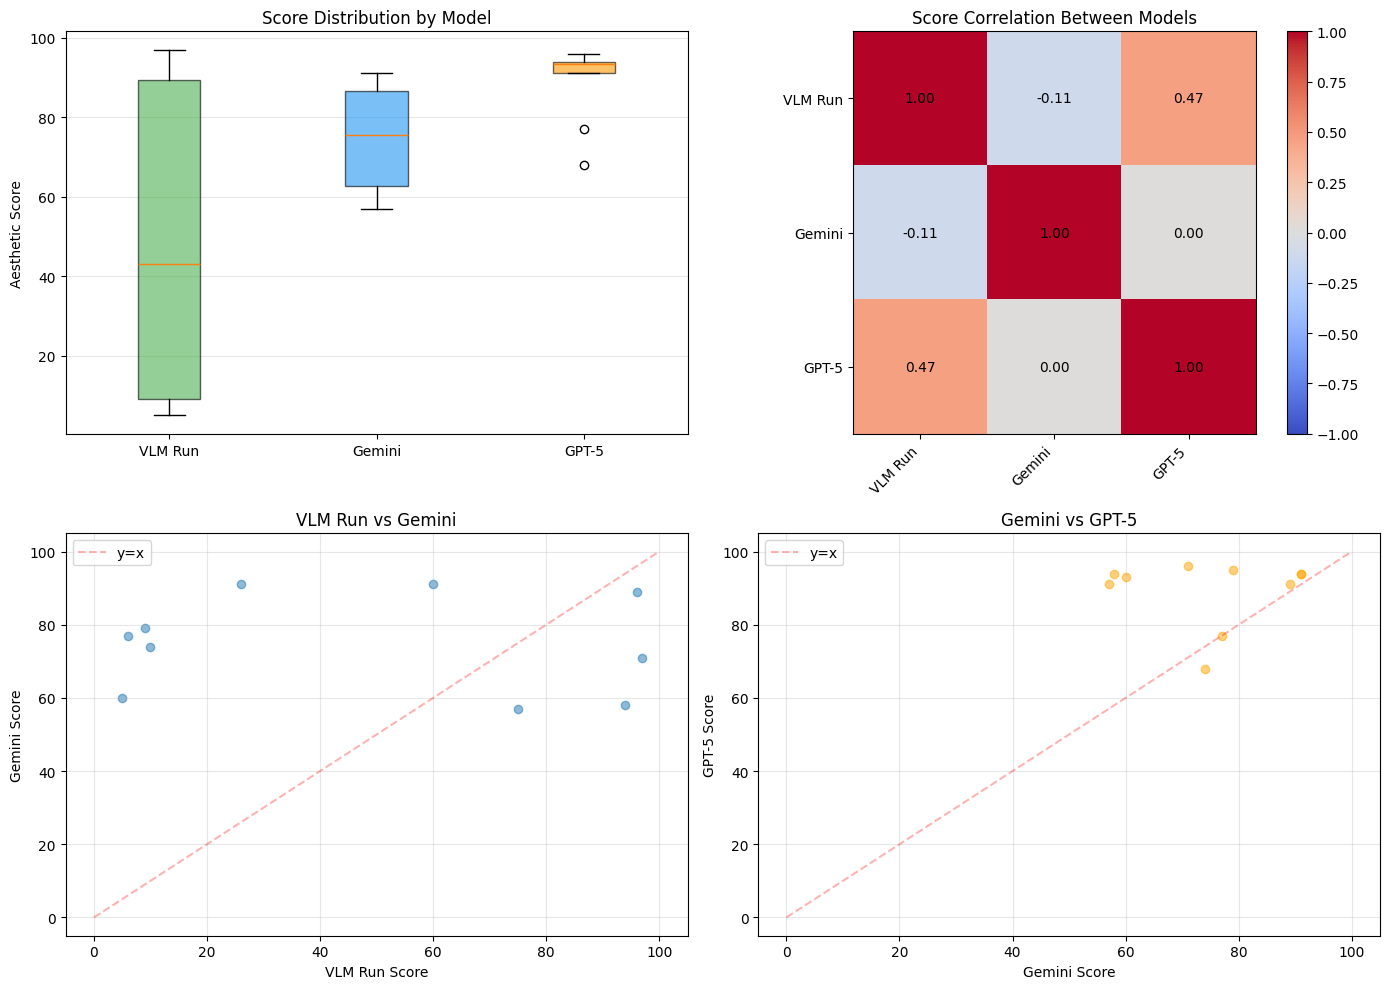

Saved comparison chart to aesthetic_score_comparison.png


In [8]:
# Comparison visualizations
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Score distributions (box plots)
ax1 = axes[0, 0]
score_data = [
    specs_df['vlmrun_score'].dropna(),
    specs_df['gemini_score'].dropna(),
    specs_df['gpt5_score'].dropna()
]
bp = ax1.boxplot(score_data, labels=['VLM Run', 'Gemini', 'GPT-5'], patch_artist=True)
for patch, color in zip(bp['boxes'], ['#4CAF50', '#2196F3', '#FF9800']):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax1.set_ylabel('Aesthetic Score')
ax1.set_title('Score Distribution by Model')
ax1.grid(axis='y', alpha=0.3)

# 2. Correlation heatmap
ax2 = axes[0, 1]
score_cols = ['vlmrun_score', 'gemini_score', 'gpt5_score']
corr = specs_df[score_cols].corr()
im = ax2.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax2.set_xticks(range(len(score_cols)))
ax2.set_yticks(range(len(score_cols)))
ax2.set_xticklabels(['VLM Run', 'Gemini', 'GPT-5'], rotation=45, ha='right')
ax2.set_yticklabels(['VLM Run', 'Gemini', 'GPT-5'])
ax2.set_title('Score Correlation Between Models')
# Add correlation values as text
for i in range(len(score_cols)):
    for j in range(len(score_cols)):
        text = ax2.text(j, i, f'{corr.iloc[i, j]:.2f}',
                       ha="center", va="center", color="black", fontsize=10)
plt.colorbar(im, ax=ax2)

# 3. Scatter plot: VLM Run vs Gemini
ax3 = axes[1, 0]
valid_data = specs_df.dropna(subset=['vlmrun_score', 'gemini_score'])
ax3.scatter(valid_data['vlmrun_score'], valid_data['gemini_score'], alpha=0.5)
ax3.plot([0, 100], [0, 100], 'r--', alpha=0.3, label='y=x')
ax3.set_xlabel('VLM Run Score')
ax3.set_ylabel('Gemini Score')
ax3.set_title('VLM Run vs Gemini')
ax3.grid(alpha=0.3)
ax3.legend()

# 4. Scatter plot: Gemini vs GPT-5
ax4 = axes[1, 1]
valid_data = specs_df.dropna(subset=['gemini_score', 'gpt5_score'])
ax4.scatter(valid_data['gemini_score'], valid_data['gpt5_score'], alpha=0.5, color='orange')
ax4.plot([0, 100], [0, 100], 'r--', alpha=0.3, label='y=x')
ax4.set_xlabel('Gemini Score')
ax4.set_ylabel('GPT-5 Score')
ax4.set_title('Gemini vs GPT-5')
ax4.grid(alpha=0.3)
ax4.legend()

plt.tight_layout()
plt.savefig('aesthetic_score_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved comparison chart to aesthetic_score_comparison.png")